# Homework 3: LLM Reasoning Data Classification

This notebook implements multiple machine learning pipelines for classifying text prompts into task types using TF-IDF and different models.

In [ ]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

In [ ]:
# Load dataset
df = pd.read_csv("../data/train_with_task_type.csv")

print(df.head())
print(df.columns)
print(df["task_type"].value_counts())

         id                                             prompt  \
0  00066667  In Alice's Wonderland, a secret bit manipulati...   
1  000b53cf  In Alice's Wonderland, a secret bit manipulati...   
2  00189f6a  In Alice's Wonderland, secret encryption rules...   
3  001b24c4  In Alice's Wonderland, numbers are secretly co...   
4  001c63cb  In Alice's Wonderland, secret encryption rules...   

                  answer         task_type task_source  task_confidence  \
0               10010111  bit_manipulation        rule             0.99   
1               01000011  bit_manipulation        rule             0.99   
2      cat imagines book       cipher_text        rule             0.99   
3                XXXVIII             roman        rule             0.98   
4  wizard creates secret       cipher_text        rule             0.99   

                                       task_reason  
0  Matched 8-bit binary / bit manipulation pattern  
1  Matched 8-bit binary / bit manipulation pat

In [ ]:
# Split data into training and testing sets
X = df['prompt']
y = df['task_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Convert text into numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
# Train Naive Bayes model
start = time.time()

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

train_time_nb = time.time() - start

start = time.time()
y_pred_nb = nb.predict(X_test_tfidf)
inference_time_nb = time.time() - start

print("Naive Bayes Results:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results:
                  precision    recall  f1-score   support

bit_manipulation       1.00      1.00      1.00       310
     cipher_text       1.00      1.00      1.00       306
         gravity       1.00      1.00      1.00       339
           roman       1.00      1.00      1.00       328
symbol_transform       1.00      1.00      1.00       289
 unit_conversion       1.00      1.00      1.00       328

        accuracy                           1.00      1900
       macro avg       1.00      1.00      1.00      1900
    weighted avg       1.00      1.00      1.00      1900



In [ ]:
# Train SVM model
start = time.time()

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

train_time_svm = time.time() - start

start = time.time()
y_pred_svm = svm.predict(X_test_tfidf)
inference_time_svm = time.time() - start

print("SVM Results:")
print(classification_report(y_test, y_pred_svm))

SVM Results:
                  precision    recall  f1-score   support

bit_manipulation       1.00      1.00      1.00       310
     cipher_text       1.00      1.00      1.00       306
         gravity       1.00      1.00      1.00       339
           roman       1.00      1.00      1.00       328
symbol_transform       1.00      1.00      1.00       289
 unit_conversion       1.00      1.00      1.00       328

        accuracy                           1.00      1900
       macro avg       1.00      1.00      1.00      1900
    weighted avg       1.00      1.00      1.00      1900



In [ ]:
# Train Random Forest model
start = time.time()

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_tfidf, y_train)

train_time_rf = time.time() - start

start = time.time()
y_pred_rf = rf.predict(X_test_tfidf)
inference_time_rf = time.time() - start

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
                  precision    recall  f1-score   support

bit_manipulation       1.00      1.00      1.00       310
     cipher_text       1.00      1.00      1.00       306
         gravity       1.00      1.00      1.00       339
           roman       1.00      1.00      1.00       328
symbol_transform       1.00      1.00      1.00       289
 unit_conversion       1.00      1.00      1.00       328

        accuracy                           1.00      1900
       macro avg       1.00      1.00      1.00      1900
    weighted avg       1.00      1.00      1.00      1900



In [ ]:
# Evaluate model performance using classification metrics
results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Train Time": [train_time_nb, train_time_svm, train_time_rf],
    "Inference Time": [inference_time_nb, inference_time_svm, inference_time_rf]
})

print(results)

           Model  Accuracy  Train Time  Inference Time
0    Naive Bayes       1.0    0.022271        0.000744
1            SVM       1.0    0.096504        0.000495
2  Random Forest       1.0    0.240345        0.016642


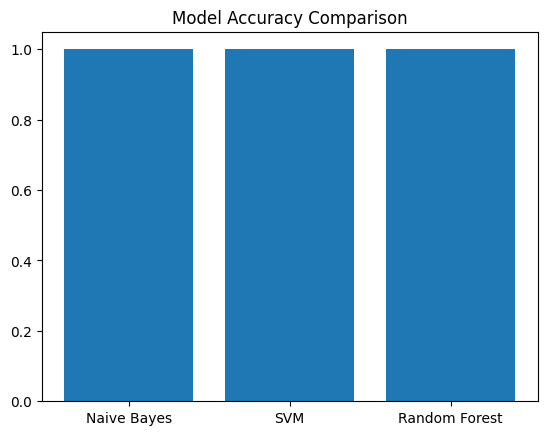

In [ ]:
# Visualize accuracy comparison between models
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.show()